# Using alternative transition probability matrices for trajectory inference

***

Jan T. Schleicher, 2025

To assess the importance of RNA velocity estimates for our exploratory trajectory inference method, we employ [Palantir](https://palantir.readthedocs.io/) and [CellRank](https://cellrank.readthedocs.io/) to compute alternative transition probability matrices that do not require RNA velocity estimates.

In [1]:
import json
import os

import cellrank as cr
import cy2path as c2p
import numpy as np
import palantir
import pandas as pd
import scanpy as sc
from cellrank.kernels import ConnectivityKernel, RealTimeKernel, PrecomputedKernel
from matplotlib import pyplot as plt
from moscot.problems import TemporalProblem

In [2]:
DATA_PATH = "../data/"
OUTPUT_PATH = "../output/alternative_tpms/"
os.makedirs(OUTPUT_PATH, exist_ok=True)

In [3]:
# Load preprocessed AnnData object
adata = sc.read_h5ad(os.path.join(DATA_PATH, "tex_data_chronic_annotated.h5ad"))
adata

AnnData object with n_obs × n_vars = 13410 × 7170
    obs: 'sampleID', 'barcode', 'sample_type', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mitochondrial', 'log1p_total_counts_mitochondrial', 'pct_counts_mitochondrial', 'total_counts_ribosomal', 'log1p_total_counts_ribosomal', 'pct_counts_ribosomal', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'phase', 'S_score', 'G2M_score', 'score_diff', 'leiden', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'annot'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mitochondrial', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'cell_cycle_genes', 'gene_count_corr', 'means', 'dispersions',

## CellRank

We use CellRank to compute two different transition probability matrices:
- based on transcriptomic similarities, using neighborhood connectivites, with the `ConnectivityKernel`
- based on experimental time points and optimal transport, with the `RealTimeKernel`

In [4]:
# Compute transition probability matrix with connectivity kernel
kernel_connectivity = ConnectivityKernel(adata)
kernel_connectivity.compute_transition_matrix()
adata.obsp["T_forward"] = kernel_connectivity.transition_matrix

In [5]:
# Compute initial and terminal states
estimator_connectivity = cr.estimators.GPCCA(kernel_connectivity)
estimator_connectivity.fit()  # n_states=[4, 20], cluster_key="leiden"
estimator_connectivity.predict_initial_states(allow_overlap=True)
estimator_connectivity.predict_terminal_states(method="eigengap")
adata.obs["root_cells"] = estimator_connectivity.initial_states_probabilities
adata.obs["end_points"] = estimator_connectivity.terminal_states_probabilities

INFO:root:Using pre-computed Schur decomposition


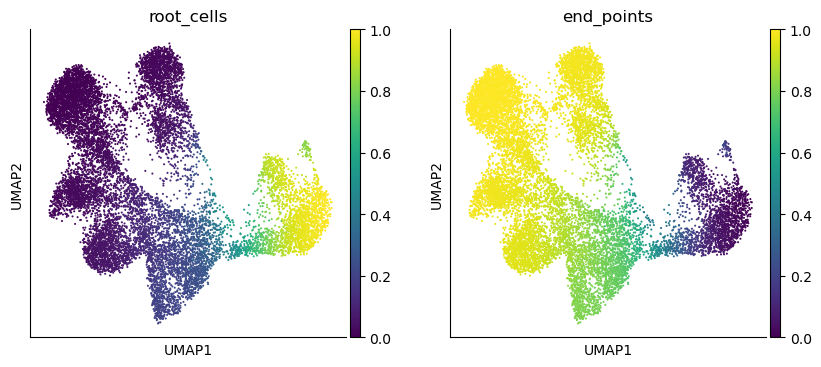

In [6]:
sc.pl.umap(
    adata,
    color=["root_cells", "end_points"],
    cmap="viridis",
    vmin=0,
    vmax=1,
)

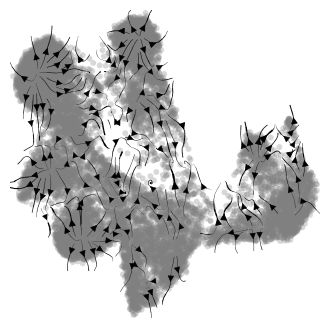

In [7]:
kernel_connectivity.plot_projection()

In [10]:
# Perform state probability sampling with different tolerance values
c2p.sample_state_probability(adata, tol=1e-5)
c2p.sample_state_probability(adata, tol=1e-4)
c2p.sample_state_probability(adata, tol=5e-4)
c2p.sample_state_probability(adata, tol=1e-3)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 644 iterations of 1000.


Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 364 iterations of 1000.


Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 184 iterations of 1000.


In [11]:
# Run Cy2path with CellRank ConnectivityKernel TPM and initial/terminal states
c2p.infer_cytopath_lineages(
    adata,
    method="linkage",
    recalc_matrix=False,
    recalc_items=True,
    num_chains=1000,
    num_lineages=2,
    tol=5e-4,
    n_jobs=-1,
)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 364 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Storing Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

/Users/janschleicher/miniconda3/envs/cytopath_moscot/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


<Axes: >

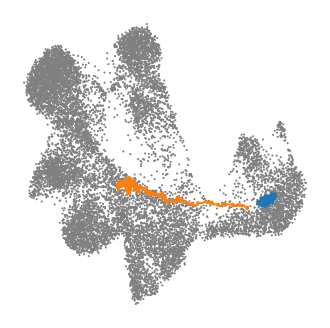

In [12]:
c2p.plot_cytopath_lineages(adata)

In [13]:
# Save TPM, root cells, and end points
np.save(
    os.path.join(OUTPUT_PATH, "tpm_cellrank_connectivity.npy"),
    estimator_connectivity.transition_matrix.toarray(),
)
estimator_connectivity.initial_states_probabilities.to_csv(
    os.path.join(OUTPUT_PATH, "root_cells_cellrank_connectivity.csv")
)
estimator_connectivity.terminal_states_probabilities.to_csv(
    os.path.join(OUTPUT_PATH, "end_points_cellrank_connectivity.csv")
)

In [15]:
# Save inferred trajectories
json.dump(
    adata.uns["markov_chain_sampling"]["sampling_params"],
    open(os.path.join(OUTPUT_PATH, "sampling_params_connectivity.json"), "w"),
)
np.save(
    os.path.join(OUTPUT_PATH, "simulations_connectivity.npy"),
    adata.uns["markov_chain_sampling"]["state_indices_max_iter"],
)
np.save(
    os.path.join(OUTPUT_PATH, "lineage_inference_clusters_connectivity.npy"),
    adata.uns["cytopath"]["lineage_inference_clusters"],
)

In [10]:
# Optimal transport with moscot
adata.obs["day"] = (
    adata.obs["timepoint"]
    .map({"d1_2_3_4": 4, "d7": 7, "d14": 14, "d21": 21})
    .astype("category")
)
tp = TemporalProblem(adata)
tp = tp.score_genes_for_marginals(
    gene_set_proliferation="mouse", gene_set_apoptosis="mouse"
)

       'Alox8', 'App', 'Atf3', 'Blcap', 'Bmp2', 'Ccp110', 'Cd81', 'Cdh13',
       'Cdk5r1', 'Cdkn2b', 'Cebpa', 'Cgrrf1', 'Clca2', 'Csrnp2', 'Ctsd',
       'Ctsf', 'Dcxr', 'Dram1', 'Epha2', 'Ephx1', 'Eps8l2', 'Gadd45a', 'Gls2',
       'Gpx2', 'Hbegf', 'Hexim1', 'Hist1h1c', 'Hist3h2a', 'Hmox1', 'Ier3',
       'Ier5', 'Il1a', 'Inhbb', 'Itgb4', 'Jag2', 'Jun', 'Klf4', 'Krt17',
       'Ldhb', 'Lif', 'Nhlh2', 'Ninj1', 'Nudt15', 'Nupr1', 'Pdgfa', 'Perp',
       'Phlda3', 'Plk2', 'Plxnb2', 'Procr', 'Ptpn14', 'Rad9a', 'Ralgds',
       'Rap2b', 'Retsat', 'Rpl18', 'Rps12', 'Rps27l', 'Rrad', 'Rxra', 'Sdc1',
       'Serpinb5', 'Sfn', 'Slc19a2', 'Slc7a11', 'Socs1', 'Sphk1', 'Steap3',
       'Stom', 'Tax1bp3', 'Tcn2', 'Tgfa', 'Tm4sf1', 'Tnni1', 'Tpd52l1',
       'Traf4', 'Trib3', 'Trp63', 'Tsc22d1', 'Upp1', 'Vdr', 'Vwa5a', 'Wrap73',
       'Zbtb16', 'Zfp365'],
      dtype='object')


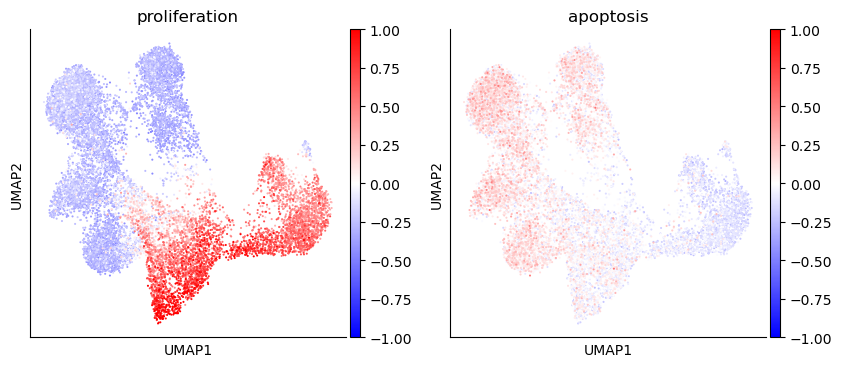

In [11]:
sc.pl.umap(
    adata, color=["proliferation", "apoptosis"], cmap="bwr", vcenter=0, vmin=-1, vmax=1
)

In [12]:
tp = tp.prepare(time_key="day")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  
INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  


In [13]:
tp = tp.solve()

INFO     Solving `3` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(4089, 3496)].                                  


INFO:2025-06-04 08:18:35,438:jax._src.xla_bridge:867: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/janschleicher/miniconda3/envs/cytopath_moscot/lib/python3.10/site-packages/jaxlib/../../../libtpu.so' (no such file), '/Users/janschleicher/miniconda3/envs/cytopath_moscot/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/janschleicher/miniconda3/envs/cytopath_moscot/lib/python3.10/site-packages/jaxlib/../../../libtpu.so' (no such file),

INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(2229, 3596)].                                  
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(3596, 4089)].                                  


In [14]:
# Compute transition probability matrix with real time kernel
kernel_realtime = RealTimeKernel.from_moscot(tp)
kernel_realtime.compute_transition_matrix()
adata.obsp["T_forward"] = kernel_realtime.transition_matrix

  0%|          | 0/3 [00:00<?, ?time pair/s]

In [23]:
# Compute initial and terminal states
estimator_realtime = cr.estimators.GPCCA(kernel_realtime)
estimator_realtime.fit(n_states=[4, 8])
estimator_realtime.predict_initial_states()
estimator_realtime.predict_terminal_states(method="eigengap")
adata.obs["root_cells"] = estimator_realtime.initial_states_probabilities
adata.obs["end_points"] = estimator_realtime.terminal_states_probabilities

INFO:root:Using pre-computed Schur decomposition
INFO:root:Using pre-computed Schur decomposition


/Users/janschleicher/miniconda3/envs/cytopath_moscot/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(
/Users/janschleicher/miniconda3/envs/cytopath_moscot/lib/python3.10/site-packages/scvelo/plotting/scatter.py:694: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
/Users/janschleicher/miniconda3/envs/cytopath_moscot/lib/python3.10/site-packages/scvelo/plotting/utils.py:1396: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=bg_size, marker=".", c=bg_color, zorder=zord - 2, **kwargs)
/Users/janschleicher/miniconda3/envs/cytopath_moscot/lib/python3.10/site-packages/scvelo/plotting/utils.py:1397: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, s=gp_size, marker=".", c=gp_color, zorder=zord - 1, 

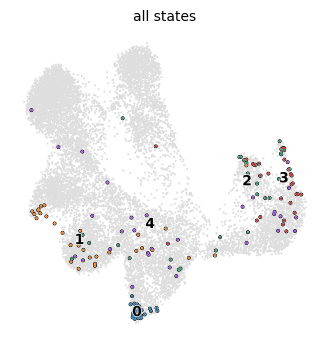

In [24]:
estimator_realtime.plot_macrostates(which="all", discrete=True)

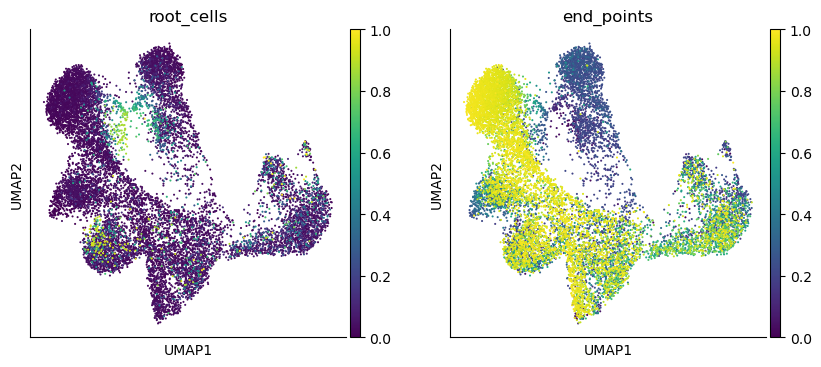

In [25]:
sc.pl.umap(
    adata,
    color=["root_cells", "end_points"],
    cmap="viridis",
    vmin=0,
    vmax=1,
)

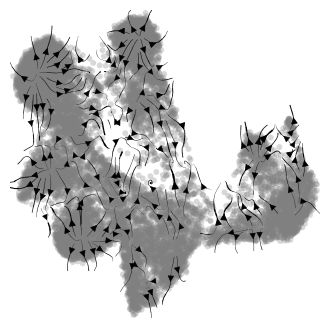

In [39]:
kernel_realtime.plot_projection()

In [27]:
# Run Cy2path with CellRank RealTimeKernel TPM and initial/terminal states
c2p.infer_cytopath_lineages(
    adata,
    method="linkage",
    recalc_matrix=False,
    recalc_items=True,
    num_chains=2000,
    num_lineages=2,
    n_jobs=-1,
)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 182 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/2000 [00:00<?, ? simulations/s]

Storing Markov chains:   0%|          | 0/2000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

/Users/janschleicher/miniconda3/envs/cytopath_moscot/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


<Axes: >

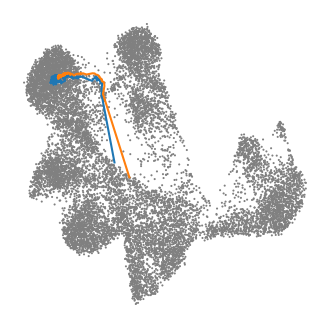

In [28]:
c2p.plot_cytopath_lineages(adata)

In [36]:
# Save TPM, root cells, and end points
np.save(
    os.path.join(OUTPUT_PATH, "tpm_cellrank_realtime.npy"),
    estimator_realtime.transition_matrix.toarray(),
)
estimator_realtime.initial_states_probabilities.to_csv(
    os.path.join(OUTPUT_PATH, "root_cells_cellrank_realtime.csv")
)
estimator_realtime.terminal_states_probabilities.to_csv(
    os.path.join(OUTPUT_PATH, "end_points_cellrank_realtime.csv")
)

## Palantir

We use Palantir to compute a transition probability matrix based solely on gene expression data.
Using CellRank, we compute initial and terminal states from the matrix.
We use this matrix to perform exploratory trajectory inference with Cy2path.

In [29]:
# Compute Palantir TPM
tpm_palantir = palantir.utils.compute_kernel(adata, knn=30)
adata.obsp["T_forward"] = tpm_palantir

In [30]:
# Use CellRank precomputed kernel to infer initial/terminal states
kernel_precomp = PrecomputedKernel(tpm_palantir)
estimator_precomp = cr.estimators.GPCCA(kernel_precomp)
estimator_precomp.fit()
estimator_precomp.predict_initial_states()
estimator_precomp.predict_terminal_states(method="eigengap")
adata.obs["root_cells"] = estimator_precomp.initial_states_probabilities.values
adata.obs["end_points"] = estimator_precomp.terminal_states_probabilities.values

INFO:root:Using pre-computed Schur decomposition


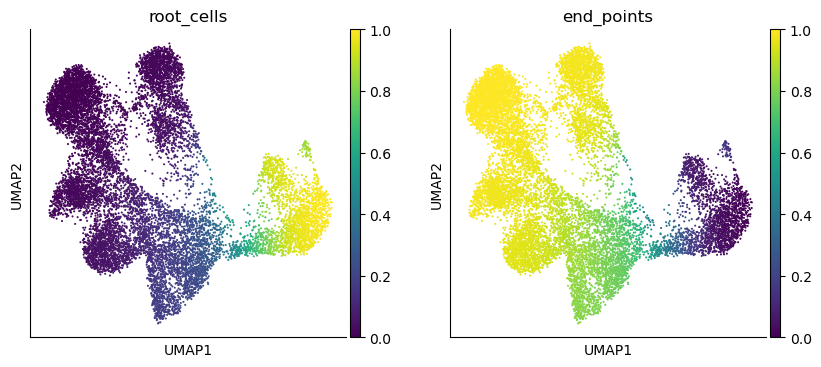

In [31]:
sc.pl.umap(
    adata,
    color=["root_cells", "end_points"],
    cmap="viridis",
    vmin=0,
    vmax=1,
)

In [32]:
# Run Cy2path with CellRank ConnectivityKernel TPM and initial/terminal states
c2p.infer_cytopath_lineages(
    adata,
    method="linkage",
    recalc_matrix=False,
    recalc_items=True,
    num_chains=2000,
    num_lineages=2,
    tol=1e-3,
    n_jobs=-1,
)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 104 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/2000 [00:00<?, ? simulations/s]

Storing Markov chains:   0%|          | 0/2000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

/Users/janschleicher/miniconda3/envs/cytopath_moscot/lib/python3.10/site-packages/scvelo/plotting/scatter.py:656: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  smp = ax.scatter(


<Axes: >

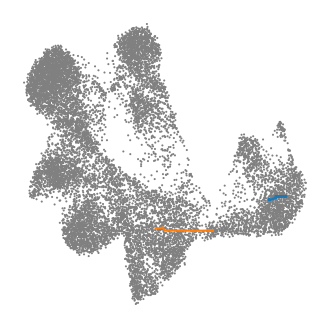

In [33]:
c2p.plot_cytopath_lineages(adata)

In [37]:
# Save TPM, root cells, and end points
np.save(
    os.path.join(OUTPUT_PATH, "tpm_palantir.npy"),
    estimator_precomp.transition_matrix.toarray(),
)
estimator_precomp.initial_states_probabilities.to_csv(
    os.path.join(OUTPUT_PATH, "root_cells_palantir.csv")
)
estimator_precomp.terminal_states_probabilities.to_csv(
    os.path.join(OUTPUT_PATH, "end_points_palantir.csv")
)